In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- -----------------

In [4]:
#titanic survival prediction
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import joblib
import shap

In [5]:
#load dataset
df = pd.read_csv('C:/Users/navee/Desktop/Titanic-Survival-Prediction/data/titanic.csv')
#display first five rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [7]:
#checking missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [9]:
#extract passenger titles
df["Title"] = df["Name"].str.extract(' ([A-Za-z]+)\.', expand=False)
#sview extracted titles
df[["Name","Title"]].head()

,Name,Title
0,"Kelly, Mr. James",Mr
1,"Wilkes, Mrs. James (Ellen Needs)",Mrs
2,"Myles, Mr. Thomas Francis",Mr
3,"Wirz, Mr. Albert",Mr
4,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",Mrs


In [10]:
#create family size feature
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
#verify familysize feature
df[["SibSp","Parch","FamilySize"]].head()

,SibSp,Parch,FamilySize
0,0,0,1
1,1,0,2
2,0,0,1
3,0,0,1
4,1,1,3


In [11]:
#create cabinpresent feature
df["CabinPresent"] = df["Cabin"].notnull().astype(int)
#verify cabinpresent feature
df[["Cabin","CabinPresent"]].head()

,Cabin,CabinPresent
0,NaN,0
1,NaN,0
2,NaN,0
3,NaN,0
4,NaN,0


In [12]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,CabinPresent
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr,1,0
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs,2,0
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mr,1,0
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Mr,1,0
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Mrs,3,0


In [13]:
df.shape

(418, 15)

In [14]:
df["Survived"].value_counts()

Survived
0    266
1    152
Name: count, dtype: int64

In [17]:
#handle missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
#filling missing values
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
#remove cabin column
df.drop("Cabin", axis=1, inplace=True)


In [24]:
#encode categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ["Sex", "Embarked", "Title"]:
    df[col] = le.fit_transform(df[col])
df.shape


(418, 11)

In [25]:
df["Survived"].value_counts()

Survived
0    266
1    152
Name: count, dtype: int64

In [26]:
#define features and target variable
X = df.drop("Survived", axis=1)
y = df["Survived"]


In [27]:
#splitting the dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
#train ml model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
#generate predictions
y_pred = model.predict(X_test)

In [45]:
#model evaluation
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
#confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84

[[50  0]
 [ 0 34]]


In [31]:
#model explainability
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
print(importance)

        Feature  Importance
1           Sex    0.642232
7         Title    0.265434
5          Fare    0.030462
2           Age    0.023188
8    FamilySize    0.015092
4         Parch    0.006882
6      Embarked    0.005293
3         SibSp    0.004886
0        Pclass    0.003814
9  CabinPresent    0.002715


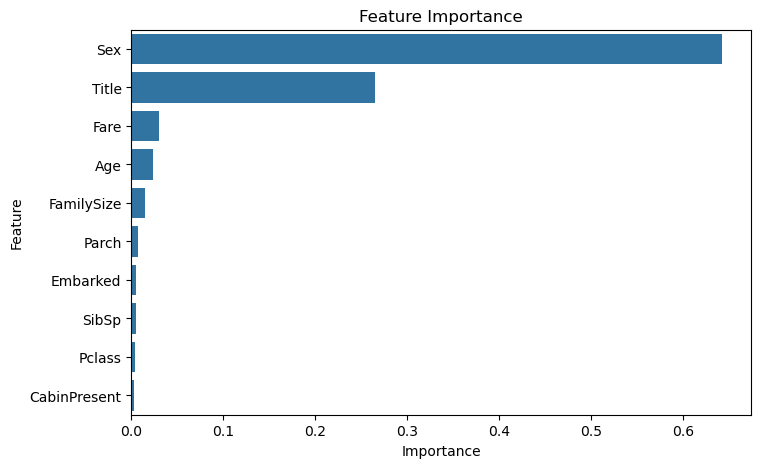

In [32]:
#visualize feature importance
plt.figure(figsize=(8,5))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance")
plt.show()

In [51]:
import joblib
joblib.dump(model, "titanic_model.pkl")


['titanic_model.pkl']

In [53]:
import os
print(os.getcwd())

C:\Users\navee\Desktop\Titanic-Survival-Prediction


In [54]:
import os
print(os.listdir())


['.ipynb_checkpoints', 'data', 'models', 'notebooks', 'titanic_model.pkl', 'Titanic_Prediction.ipynb', 'Untitled.ipynb']


In [55]:
import os
for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".pkl"):
            print(os.path.join(root, file))


.\titanic_model.pkl
.\models\titanic_model.pkl


In [58]:
loaded_model = joblib.load("titanic_model.pkl")

In [42]:
#create sample dataset
sample = pd.DataFrame([{
    "Pclass": 1,
    "Sex": 0,
    "Age": 30,
    "SibSp": 1,
    "Parch": 0,
    "Fare": 80,
    "Embarked": 2,
    "Title": 2,
    "FamilySize": 2,
    "CabinPresent": 1
}])

In [43]:
prediction = loaded_model.predict(sample)
print("Prediction:", prediction[0])

Prediction: 1
